# Exploratory Data Analysis

In [1]:
from bioacoustics.data import load_results, load_metadata

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Here, analyze collected features (do dimension reduction, etc.). Analyze species presence, class balance...

In [3]:
data_train = load_results("features", "data_train", frozen=True)
data_train_soundscapes = load_results("features", "data_train_soundscapes")
_, _, df_taxonomy = load_metadata()
primary_to_class = dict(zip(df_taxonomy["primary_label"], df_taxonomy["class_name"]))

In [4]:
data_train["y_class"].value_counts()

Amphibia  Aves  Insecta  Mammalia  Reptilia
0         1     0        0         0           32254
1         0     0        0         0             422
0         0     1        0         0             192
                0        1         0              79
                         0         1               1
Name: count, dtype: int64

In [5]:
data_train_soundscapes["y_class"].value_counts()

Amphibia  Aves  Insecta  Mammalia  Reptilia
1         0     0        0         0           866
          1     0        0         0           188
0         1     1        0         0           162
          0     1        0         0            78
1         0     1        0         0            46
0         1     0        0         0            30
1         1     0        1         0            26
0         0     0        1         0            24
                1        1         0            22
                         0         1            12
          1     1        0         1            12
1         0     0        1         0             4
0         1     0        1         0             4
1         1     1        0         0             2
0         0     1        1         1             2
Name: count, dtype: int64

In [6]:
data_train["metadata"]

,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,collection
filename,,,,,,,,,,,,,
1161364/iNat1216197.ogg,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,iNat
1161364/iNat1114648.ogg,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,iNat
1161364/iNat810195.ogg,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,iNat
1161364/iNat818781.ogg,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,iNat
1161364/iNat556514.ogg,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,iNat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
yeofly1/XC762473.ogg,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,XC
yeofly1/XC818328.ogg,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,XC
yeofly1/XC425545.ogg,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,XC


Distribution of `data_train` and `data_train_soundscapes`

In [7]:
import matplotlib.pyplot as plt

In [8]:
data_train["y_class"]

,Amphibia,Aves,Insecta,Mammalia,Reptilia
filename,,,,,
1161364/iNat1216197.ogg,0,0,1,0,0
1161364/iNat1114648.ogg,0,0,1,0,0
1161364/iNat810195.ogg,0,0,1,0,0
1161364/iNat818781.ogg,0,0,1,0,0
1161364/iNat556514.ogg,0,0,1,0,0
...,...,...,...,...,...
yeofly1/XC762473.ogg,0,1,0,0,0
yeofly1/XC818328.ogg,0,1,0,0,0
yeofly1/XC425545.ogg,0,1,0,0,0


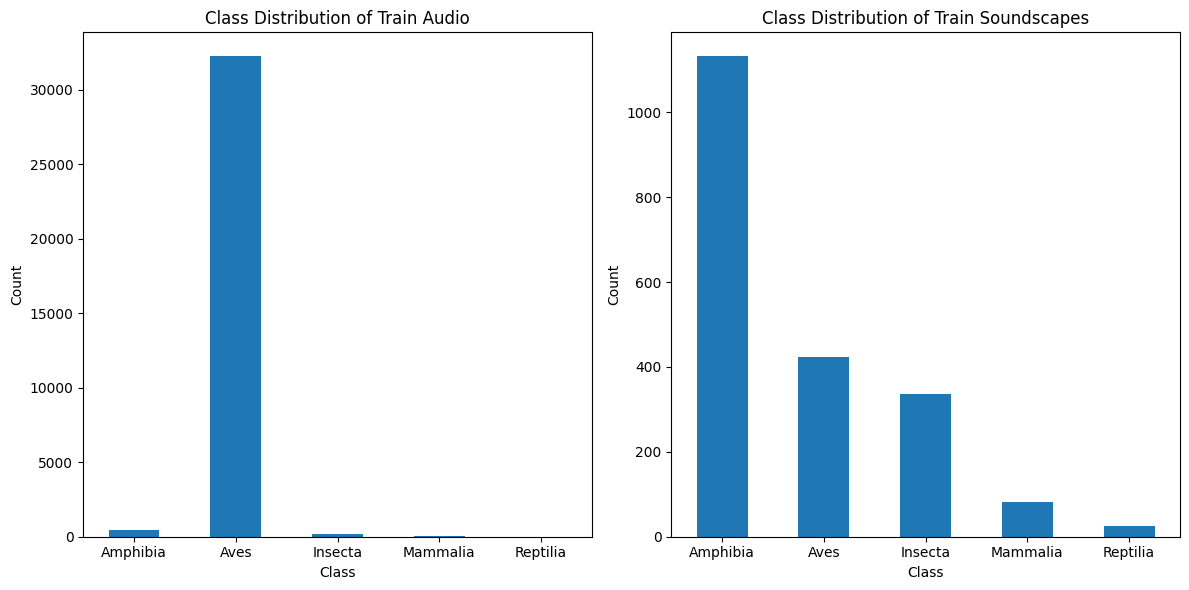

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

data_train["y_class"].sum().plot.bar(ax=axes[0])
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution of Train Audio")
axes[0].tick_params(axis="x", rotation=0)

data_train_soundscapes["y_class"].sum().plot.bar(ax=axes[1])
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_title("Class Distribution of Train Soundscapes")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

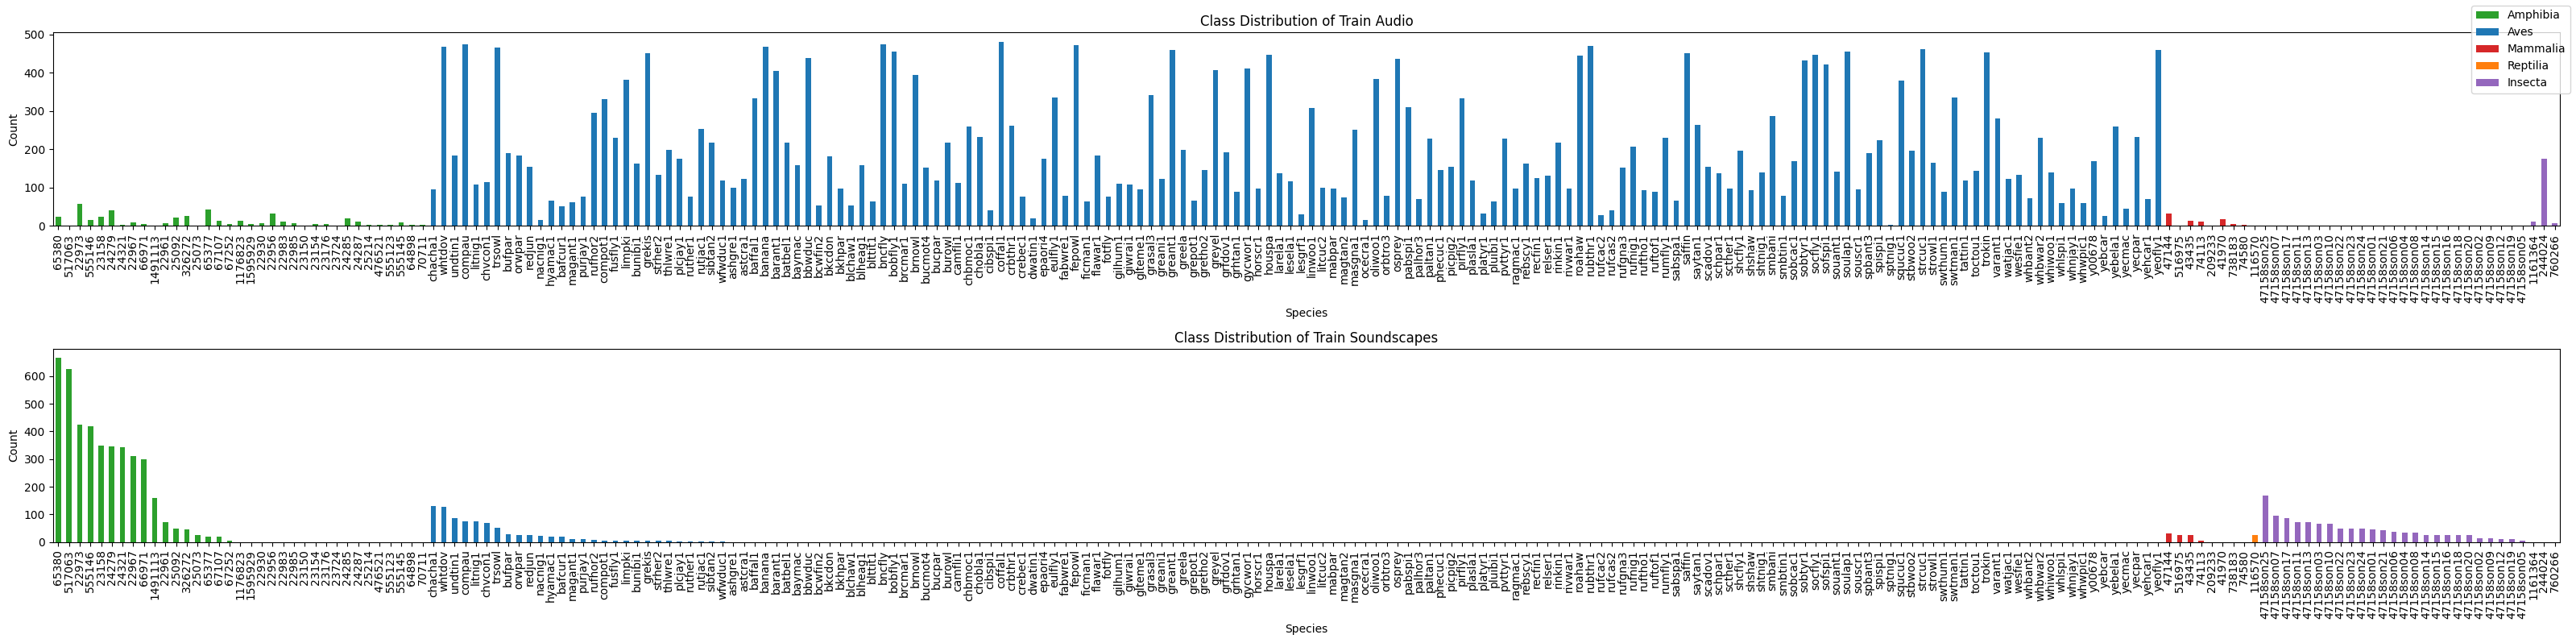

In [10]:
from matplotlib.patches import Patch

# Color mapping
class_colors = {
    "Amphibia": "tab:green",
    "Aves": "tab:blue",
    "Mammalia": "tab:red",
    "Reptilia": "tab:orange",
    "Insecta": "tab:purple",
}

#
# Counts
#
counts_train = data_train["y_primary"].sum()
counts_sound = data_train_soundscapes["y_primary"].sum()

#
# Build dataframe using SOUND frequencies
# to define the global ordering
#
df_order = pd.DataFrame(
    {
        "sound_count": counts_sound,
    }
)

df_order["class"] = df_order.index.map(primary_to_class)

# same class order everywhere
class_order = [
    "Amphibia",
    "Aves",
    "Mammalia",
    "Reptilia",
    "Insecta",
]

df_order["class"] = pd.Categorical(
    df_order["class"],
    categories=class_order,
    ordered=True,
)

#
# Sort:
#   1. by class
#   2. by soundscape frequency
#
df_order = df_order.sort_values(
    by=["class", "sound_count"],
    ascending=[True, False],
)

# final common species ordering
species_order = df_order.index

# Reindex both datasets with same ordering
counts_train = counts_train.reindex(species_order)
counts_sound = counts_sound.reindex(species_order)

# Colors
classes = [primary_to_class[label] for label in species_order]
colors = [class_colors[c] for c in classes]

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(32, 8))

counts_train.plot.bar(
    ax=axes[0],
    color=colors,
)

axes[0].set_xlabel("Species")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution of Train Audio")

counts_sound.plot.bar(
    ax=axes[1],
    color=colors,
)

axes[1].set_xlabel("Species")
axes[1].set_ylabel("Count")
axes[1].set_title("Class Distribution of Train Soundscapes")

# Legend
legend_elements = [
    Patch(facecolor=color, label=cls) for cls, color in class_colors.items()
]

fig.legend(handles=legend_elements)

fig.tight_layout()
plt.show()

We see that the distribution between `train_audio` and `train_soundscapes` is very different, so we need to be careful when we work between them.

Correlation matrix

In [11]:
corr_matrix = data_train_soundscapes["X"].corr()

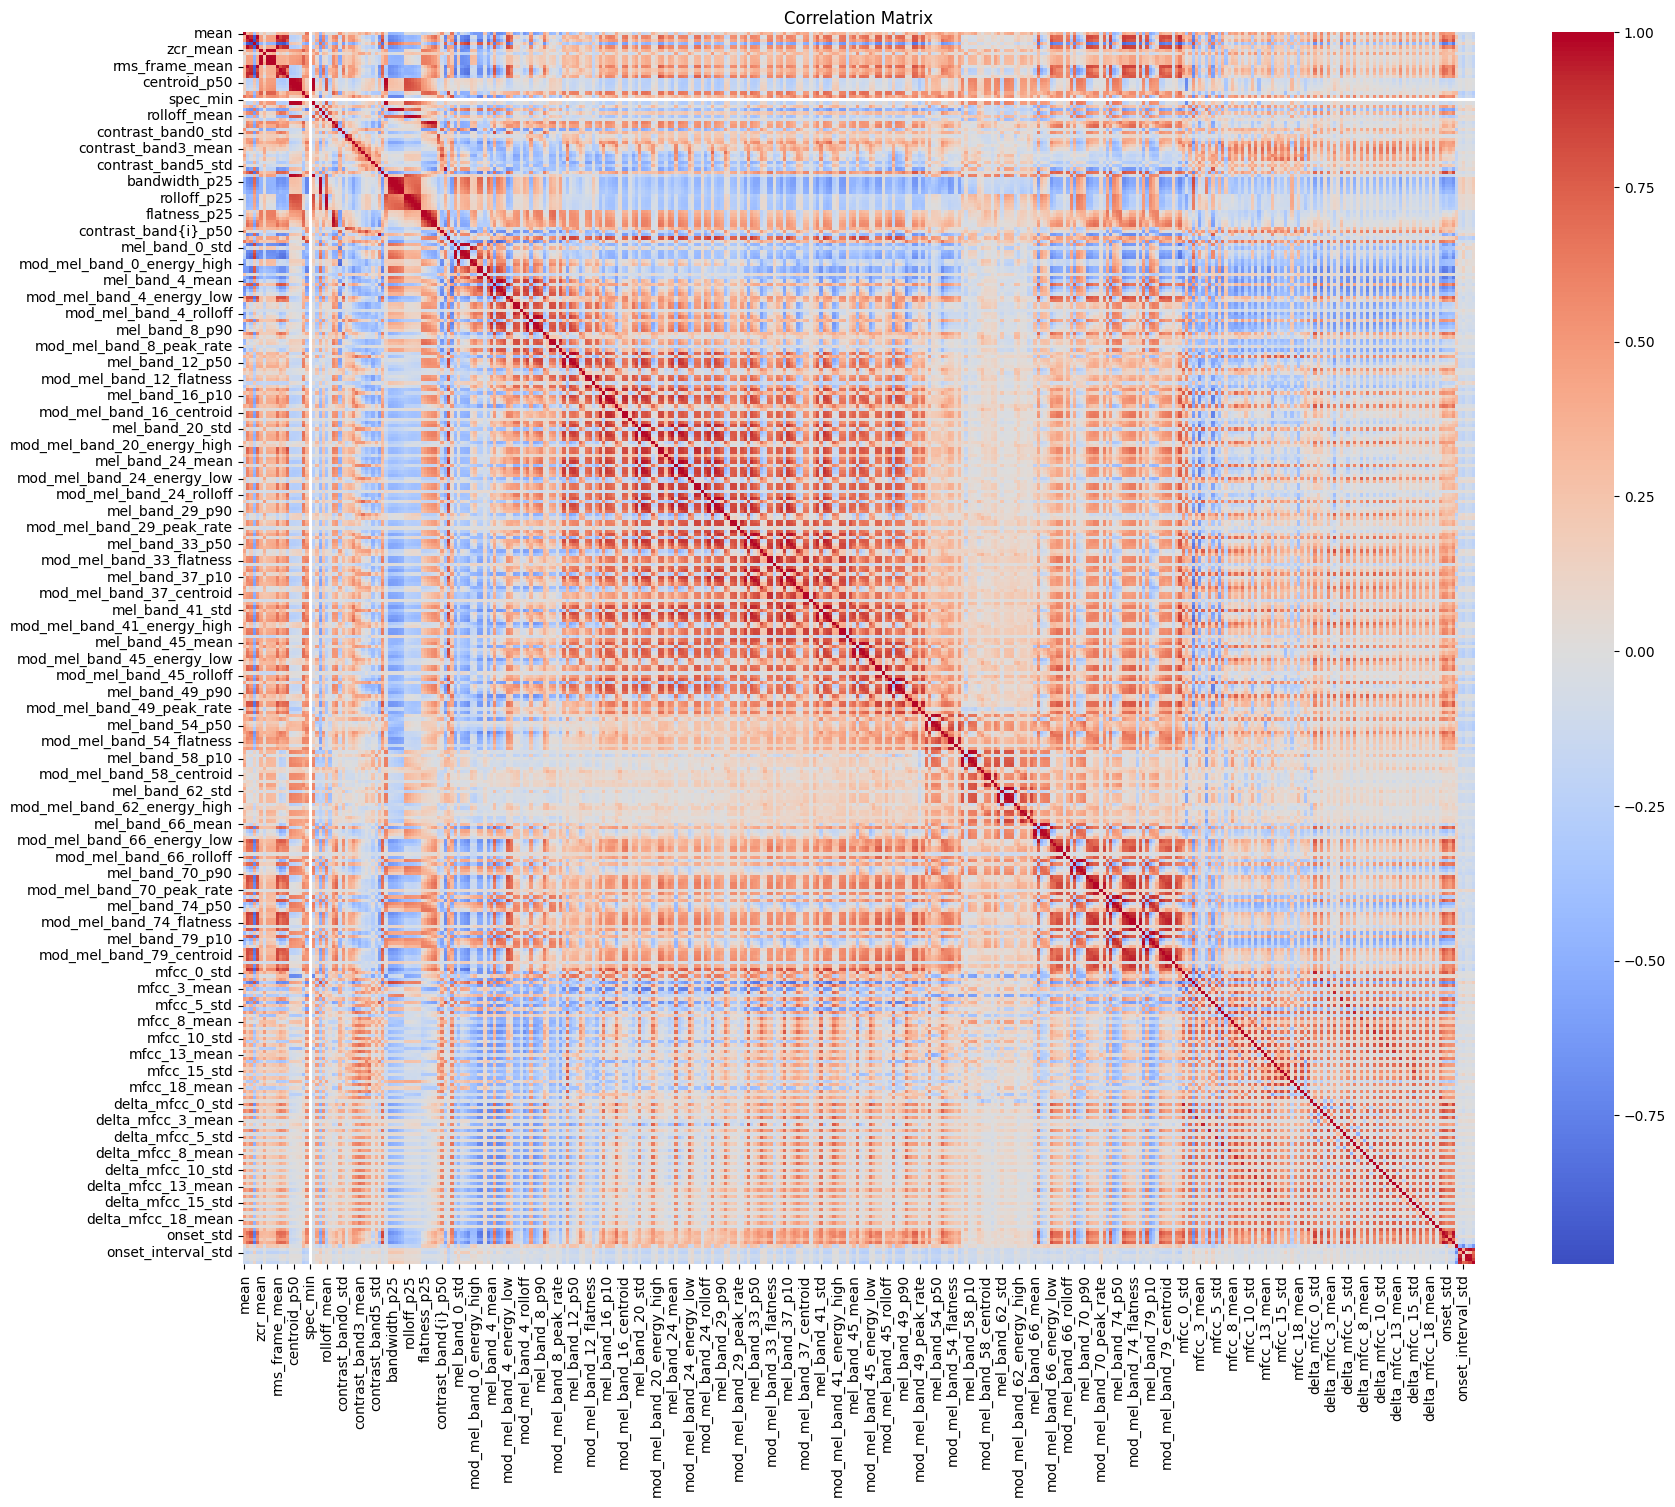

In [12]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Correlation Matrix")
plt.show()

We can see some "boxes" of high correlation usually around the same type of features (e.g. `mode_mel_band`). Let's let's see what are the most correlated variables

In [13]:
# Flatten correlation matrix into pairs
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs = corr_pairs.dropna()

# Rename columns
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Sort by absolute correlation (strongest first)
corr_pairs = corr_pairs.reindex(
    corr_pairs["correlation"].abs().sort_values(ascending=False).index
)

corr_pairs

,feature_1,feature_2,correlation
24003,mel_band_0_mean,mel_band_0_p50,0.999625
1878,zcr_mean,zcr_p50,0.999278
5631,centroid_p50,centroid_mean,0.998564
85878,mel_band_62_mean,mel_band_62_p50,0.998281
69378,mel_band_45_mean,mel_band_45_p50,0.998269
...,...,...,...
111058,mfcc_6_mean,delta_mfcc_15_mean,0.000021
80255,mod_mel_band_54_centroid,mel_band_58_std,0.000021
1478,min,delta_mfcc_16_mean,0.000018
56370,mod_mel_band_29_peak_rate,mod_mel_band_74_flatness,0.000009


In [14]:
(corr_pairs["correlation"] > 0.90).sum()

np.int64(371)

We can look into doing something like correlation filtering in order to remove features that are too correlated. Depending on the type of model we use later this can help.

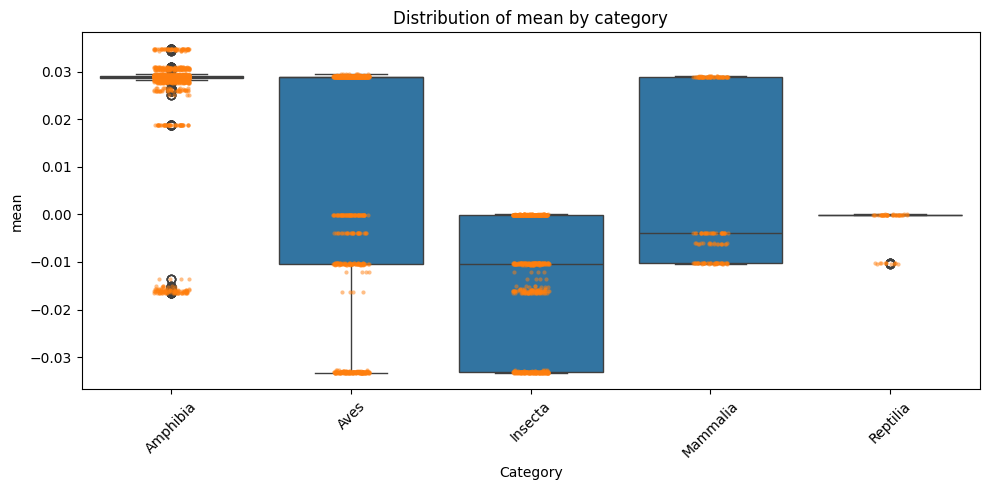

In [15]:
def plot_feature_distribution(
    data,
    feature,
    figsize=(10, 5),
    jitter=True,
    alpha=0.5,
    point_size=3,
):
    x = data["X"][[feature]]
    y = data["y_class"]

    # Convert one-hot labels to long format
    df_plot = (
        x.join(y)
        .melt(
            id_vars=feature,
            var_name="category",
            value_name="active",
        )
        .query("active == 1")
    )

    fig, ax = plt.subplots(figsize=figsize)

    # Boxplot
    sns.boxplot(
        data=df_plot,
        x="category",
        y=feature,
        ax=ax,
    )

    # Individual points
    sns.stripplot(
        data=df_plot,
        x="category",
        y=feature,
        ax=ax,
        jitter=jitter,
        alpha=alpha,
        size=point_size,
    )

    ax.set_title(f"Distribution of {feature} by category")
    ax.set_xlabel("Category")
    ax.set_ylabel(feature)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_feature_distribution(data_train_soundscapes, "mean")

It is strange that the means are in such clear bands. This may be an artifact to the different recording stations that may not carry over well into the test dataset.

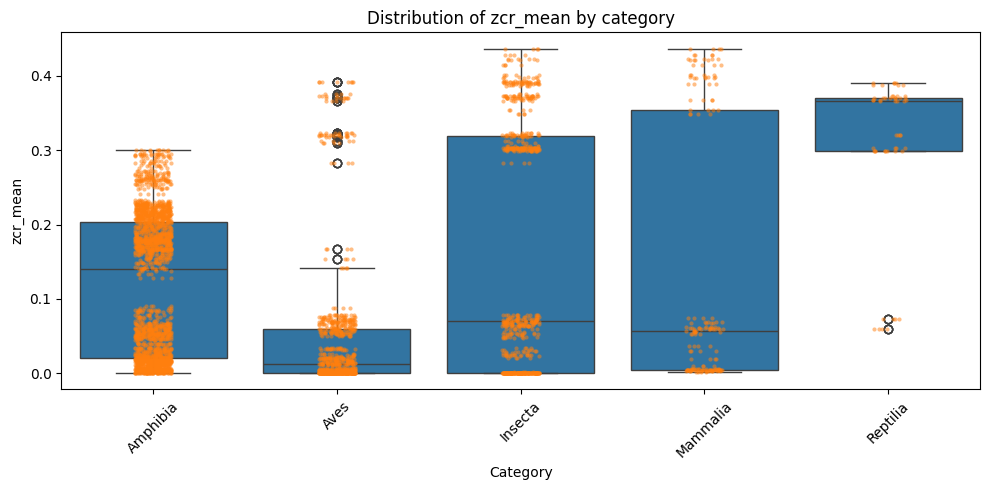

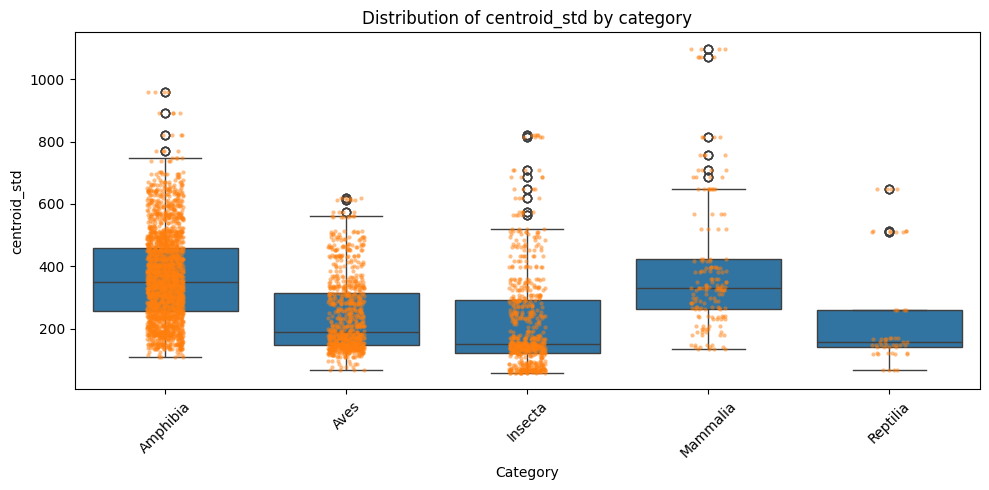

In [16]:
plot_feature_distribution(data_train_soundscapes, "zcr_mean")
plot_feature_distribution(data_train_soundscapes, "centroid_std")

Principle Component Analysis

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Features
X = data_train_soundscapes["X"]

# Labels
y = data_train_soundscapes["y_class"]

# Standardize features (VERY important for PCA)
X_scaled = StandardScaler().fit_transform(X)

# PCA to 10 dimensions
pca = PCA(n_components=10)

X_pca = pca.fit_transform(X_scaled)

In [18]:
print(
    f"Explained Variance Ration with 10 dimensions: {pca.explained_variance_ratio_.sum():.2f}"
)

Explained Variance Ration with 10 dimensions: 0.72


In [19]:
print(X.shape)
print(X_scaled.shape)
print(X_pca.shape)
print(y.shape)

(1478, 374)
(1478, 374)
(1478, 10)
(1478, 5)


With multiple labels split into differe

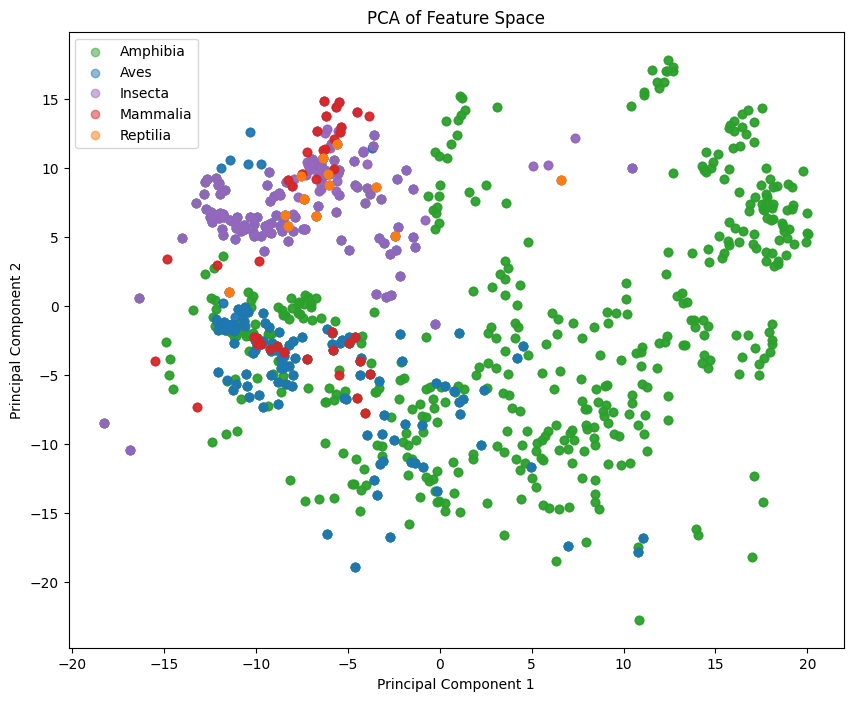

In [20]:
# Convert y into two points if it contains multiple labels
# TODO: Investigate whether it overrides some of the class
df_pca = (
    pd.DataFrame(
        {
            "PC1": X_pca[:, 0],
            "PC2": X_pca[:, 1],
        },
        index=y.index,
    )
    .join(y)
    .melt(
        id_vars=["PC1", "PC2"],
        var_name="y_class",
        value_name="active",
    )
    .query("active == 1")
)

plt.figure(figsize=(10, 8))

for cls in df_pca["y_class"].unique():
    subset = df_pca[df_pca["y_class"] == cls]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        color=class_colors[cls],
        label=cls,
        alpha=0.5,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Feature Space")
plt.legend()
plt.show()

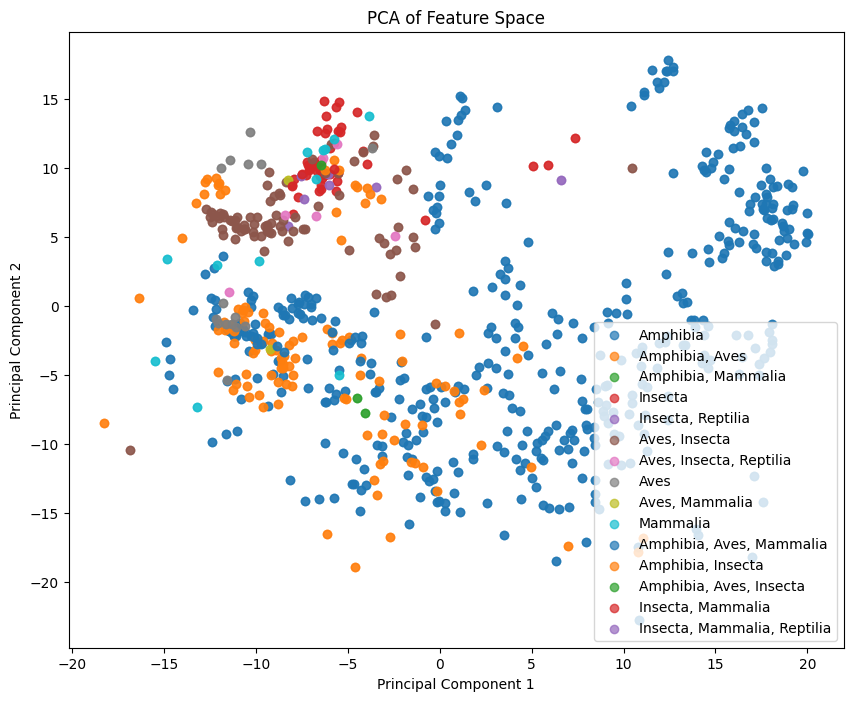

In [21]:
# Put into dataframe
y_labels = y.apply(
    lambda row: ", ".join(row.index[row == 1]),
    axis=1,
)

df_pca = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "y_class": y_labels.values,
    }
)

# Plot
plt.figure(figsize=(10, 8))

for cls in df_pca["y_class"].unique():
    subset = df_pca[df_pca["y_class"] == cls]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=cls,
        alpha=0.7,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Feature Space")
plt.legend()
plt.show()

PCA Circle

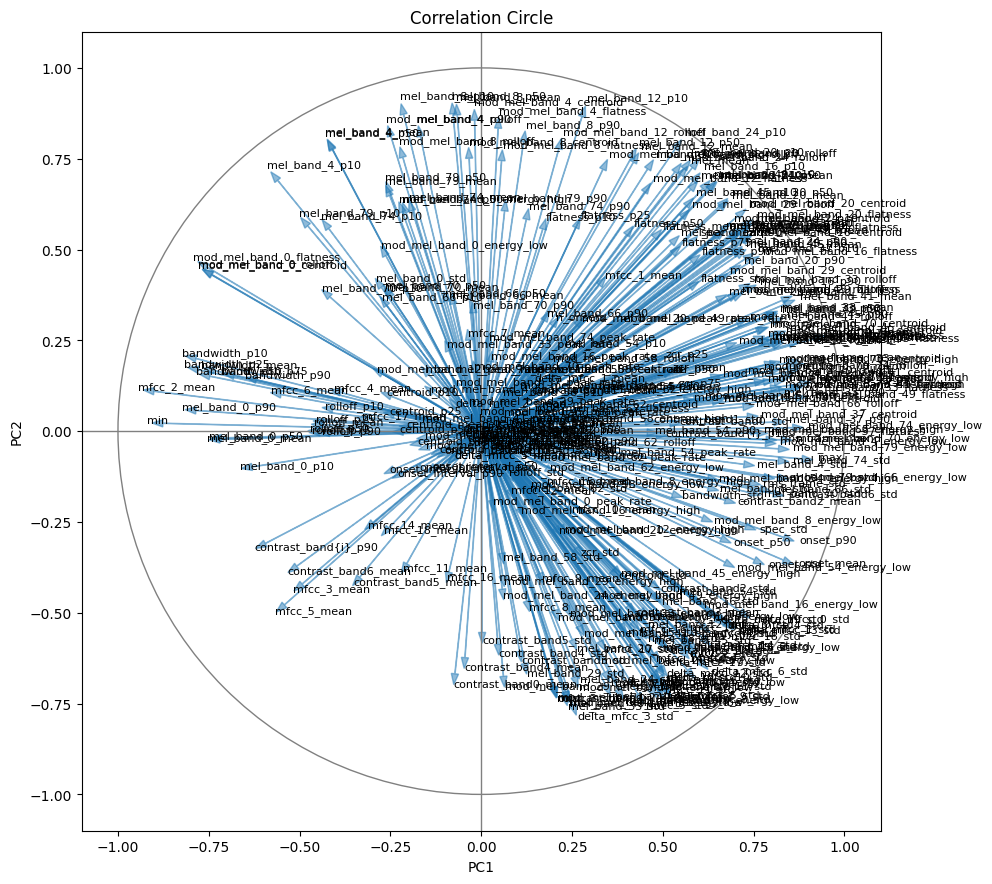

In [22]:
# Feature names
features = X.columns

# Loadings
loadings = pca.components_.T

# Scale by explained variance
loadings = loadings * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Draw unit circle
circle = plt.Circle((0, 0), 1, color="gray", fill=False)
ax.add_artist(circle)

# Draw arrows
for i, feature in enumerate(features):
    x_vector = loadings[i, 0]
    y_vector = loadings[i, 1]

    ax.arrow(
        0,
        0,
        x_vector,
        y_vector,
        color="tab:blue",
        alpha=0.5,
        head_width=0.02,
    )

    ax.text(
        x_vector * 1.05,
        y_vector * 1.05,
        feature,
        fontsize=8,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Correlation Circle")

ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

ax.set_aspect("equal")

plt.tight_layout()
plt.show()